In [ ]:
from galpy.potential import HernquistPotential
from tambora.dynamics import ExternalGalpyPotential
from WidrowKaiserFDM import WidrowKaiserFDM
import numpy as np, astropy.units as u
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
from matplotlib.patches import Circle
from galpy.util.coords import rect_to_cyl, cyl_to_rect_vec

from astropy.constants import c

In [17]:
ro, vo = 8.0, 220.
a = 10.0 * u.kpc
M = 1e9 * u.Msun
targetPotential = HernquistPotential(amp=2*M, a=a, ro=ro*u.kpc, vo=vo*u.km/u.s)
targetPotential.turn_physical_on()

mboson = 1e-22 * u.eV / c**2
L = 20


Number of radial solutions for l = 0: 33
Number of radial solutions for l = 1: 32
Number of radial solutions for l = 2: 32
Number of radial solutions for l = 3: 31
Number of radial solutions for l = 4: 30
Number of radial solutions for l = 5: 30
Number of radial solutions for l = 6: 29
Number of radial solutions for l = 7: 28
Number of radial solutions for l = 8: 27
Number of radial solutions for l = 9: 27
Number of radial solutions for l = 10: 26
Number of radial solutions for l = 11: 25
Number of radial solutions for l = 12: 24
Number of radial solutions for l = 13: 24
Number of radial solutions for l = 14: 23
Number of radial solutions for l = 15: 22
Number of radial solutions for l = 16: 21
Number of radial solutions for l = 17: 20
Number of radial solutions for l = 18: 19
Number of radial solutions for l = 19: 19
Number of radial solutions for l = 20: 18
Number of radial solutions for l = 21: 17
Number of radial solutions for l = 22: 16
Number of radial solutions for l = 23: 15
Nu

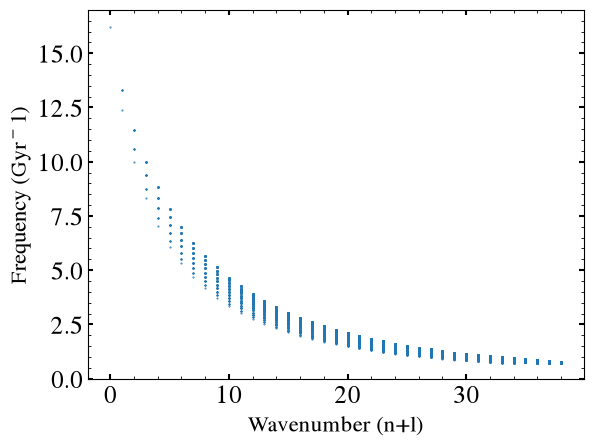

In [42]:
totalForce = WidrowKaiserFDM(targetPotential, mboson, L, update_freq = 0.05, N=500)
targetForce = ExternalGalpyPotential(targetPotential)
fdmAcc = lambda pos, t: totalForce.acc(pos, t) - targetForce.acc(pos, t)
fdmPot = lambda pos, t: totalForce.potential(pos, t) - targetForce.potential(pos, t)

# Potential Field

In [24]:
nx, ny = 51, 51
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

# potential() returns a scalar field of shape (N,), one value per position, so
# it must be reshaped onto the (ny, nx) grid before pcolormesh (unlike acc(),
# which is an (N, 3) vector). Plot |Phi| so the (negative) potential stays
# positive for LogNorm.
mag_20kpc = np.abs(
    np.asarray(totalForce.potential(pos_grid_20kpc, t=0.0)).reshape(X_20kpc.shape)
)

plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Potential magnitude [kpc$^2$/Gyr$^2$]')
plt.title('Total Potential', fontsize=22)
plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

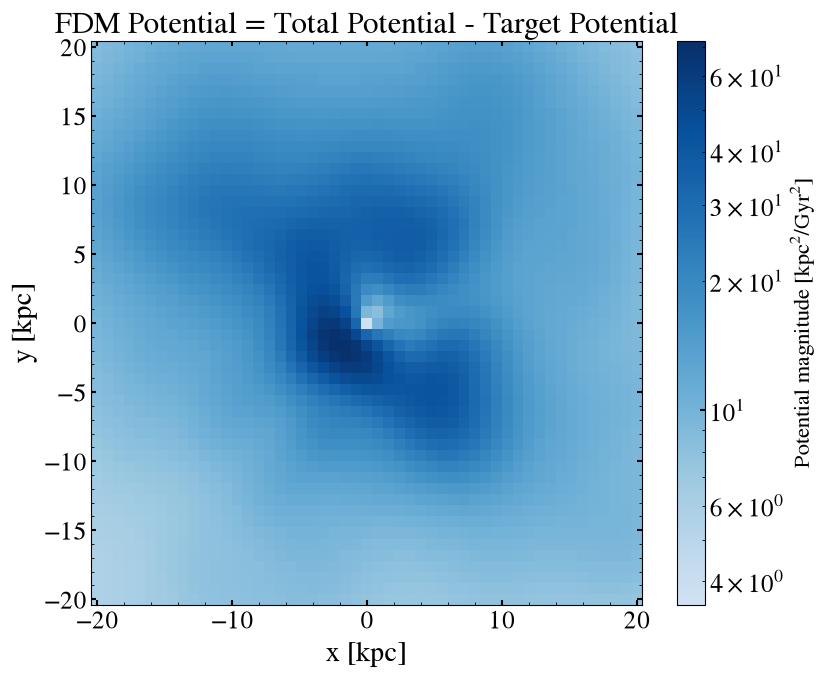

In [20]:
nx, ny = 51, 51
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

# potential() returns a scalar field of shape (N,), one value per position, so
# it must be reshaped onto the (ny, nx) grid before pcolormesh (unlike acc(),
# which is an (N, 3) vector). Plot |Phi| so the (negative) potential stays
# positive for LogNorm.
mag_20kpc = np.abs(
    np.asarray(fdmPot(pos_grid_20kpc, t=0.0)).reshape(X_20kpc.shape)
)

plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Potential magnitude [kpc$^2$/Gyr$^2$]')
plt.title('FDM Potential = Total Potential - Target Potential', fontsize=22)
plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.tight_layout()
plt.show()

# Acceleration Field

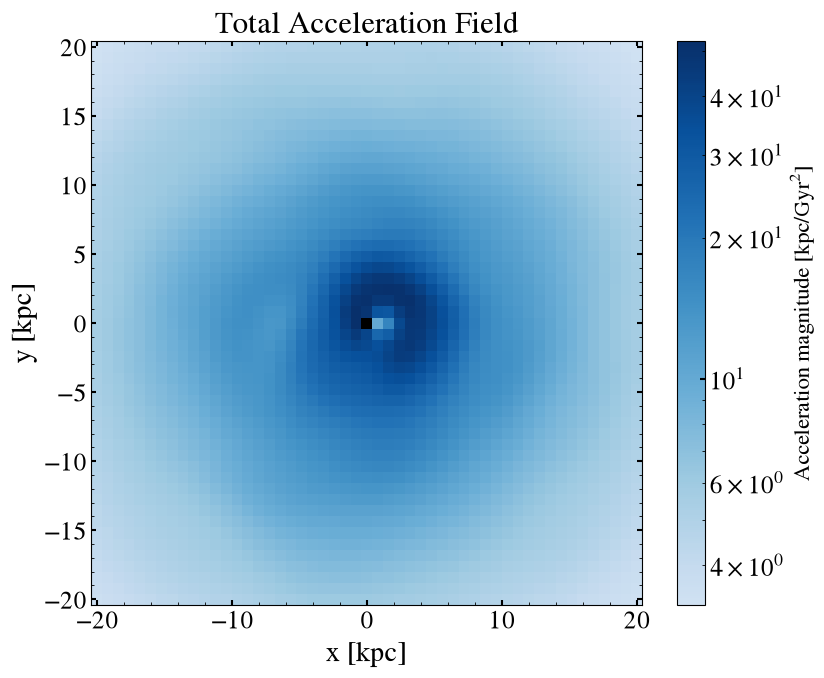

In [21]:
nx, ny = 51, 51
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

net_acc_grid_20kpc = totalForce.acc(pos_grid_20kpc, t=3.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')
plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.title('Total Acceleration Field', fontsize=22)

plt.tight_layout()
plt.show()

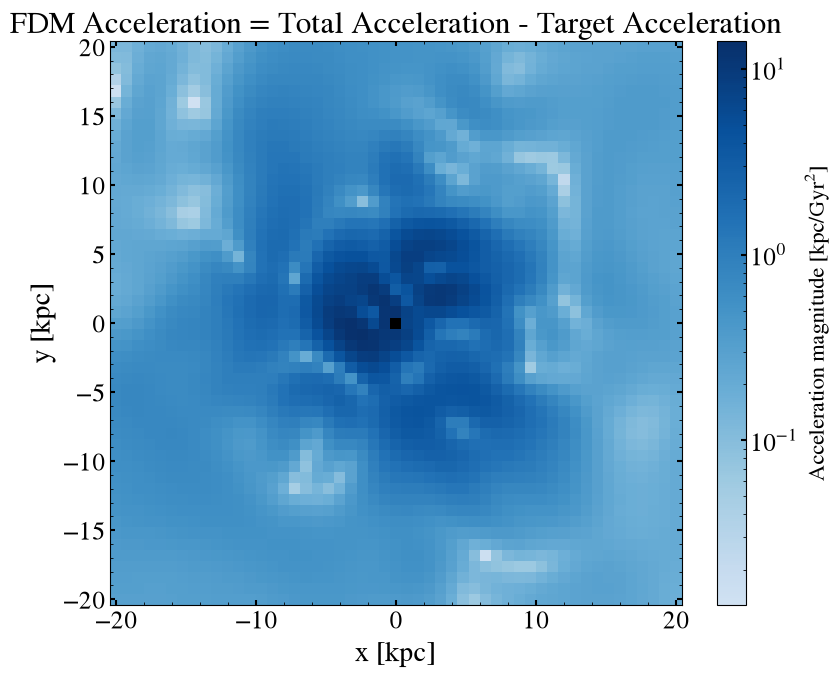

In [25]:
nx, ny = 51, 51
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

net_acc_grid_20kpc = fdmAcc(pos_grid_20kpc, t=3.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')
plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.title('FDM Acceleration = Total Acceleration - Target Acceleration', fontsize=22)
plt.tight_layout()
plt.show()

# Animations

Time-evolution of the four colormaps above. Each animation sweeps the field
over `anim_times` (Gyr) and shares a fixed color scale across frames.

In [44]:
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm
from IPython.display import HTML


def animate_colormap(field_fn, times, label='Field magnitude',
                     nx=51, ny=51, buffer=20, interval=200, filename=None):
    """Animate the magnitude of a field over time.

    ``field_fn(pos_grid, t=...)`` may return either an (N, >=2) vector field
    (e.g. acc(), whose columns 0 and 1 are combined in quadrature) or an (N,)
    scalar field (e.g. potential(), whose absolute value is taken). Returns an
    HTML (jshtml) animation for inline display in the notebook.
    """
    x = np.linspace(-buffer, buffer, nx)
    y = np.linspace(-buffer, buffer, ny)
    X, Y = np.meshgrid(x, y)
    pos_grid = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])

    def _magnitude(net):
        net = np.asarray(net)
        if net.ndim == 1 or net.shape[-1] == 1:  # scalar field (e.g. potential)
            return np.abs(net.reshape(X.shape))
        U = net[:, 0].reshape(X.shape)           # vector field (e.g. acc)
        V = net[:, 1].reshape(X.shape)
        return np.hypot(U, V)

    # Pre-compute every frame and a shared (time-independent) color scale.
    frames = [_magnitude(field_fn(pos_grid, t=t)) for t in times]
    vmin = min(np.nanmin(f) for f in frames)
    vmax = max(np.nanmax(f) for f in frames)

    cmap = plt.cm.colors.ListedColormap(plt.cm.Blues(np.linspace(0.2, 1.0, 256)))
    cmap.set_bad('k')
    norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8.5, 7))
    pcm = ax.pcolormesh(X, Y, frames[0], shading='auto', cmap=cmap, norm=norm)
    fig.colorbar(pcm, ax=ax, label=label)
    ax.set_xlabel("x [kpc]", fontsize=20)
    ax.set_ylabel("y [kpc]", fontsize=20)
    title = ax.set_title(f"t = {times[0]:.2f} Gyr")
    fig.tight_layout()

    def update(i):
        pcm.set_array(frames[i].ravel())
        title.set_text(f"t = {times[i]:.2f} Gyr")
        return pcm, title

    anim = FuncAnimation(fig, update, frames=len(times), interval=interval, blit=False)
    plt.close(fig)  # avoid showing a static duplicate of the first frame
    if filename is not None:
        anim.save(filename)
    else:
        return HTML(anim.to_jshtml())
    

# Time samples shared by the animations below (Gyr); adjust range/resolution as needed.
anim_times = np.linspace(0.0, 2.0, 21)

In [39]:
# Animated potential field — FDM force only
# animate_colormap(fdmForce.potential, anim_times)

In [40]:
# Animated potential field — total force (FDM + target)
#animate_colormap(totalForce.potential, anim_times)

In [45]:
# Animated acceleration field — FDM force only
animate_colormap(fdmAcc, anim_times, filename='FDMacc.gif', label='FDM Acceleration = Total Acc - Target Acc')

In [ ]:
# Animated acceleration field — total force (FDM + target)
animate_colormap(totalForce.acc, anim_times)

KeyboardInterrupt: 